In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_hub
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")

# ── Verificar GPU ─────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ Usando GPU: {gpus[0].name}")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("⚠️  GPU no encontrada, usando CPU")

2026-06-04 08:21:35.358026: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-04 08:21:35.365412: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780561295.374235    2418 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780561295.377178    2418 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-04 08:21:35.387039: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

TensorFlow version: 2.18.1
✅ Usando GPU: /physical_device:GPU:0


In [ ]:
TRAIN_DIR   = '/workspace/dataset/train/'
TEST_DIR    = '/workspace/dataset/test/'

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 1e-3
DROPOUT     = 0.2
PATIENCE    = 5
VAL_SPLIT   = 0.2
SEED        = 123
AUTOTUNE    = tf.data.AUTOTUNE

# Subconjunto para pruebas rápidas (poner None para usar el dataset completo)
TRAIN_SAMPLES = None
TEST_SAMPLES  = None

In [ ]:
train_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,   # <-- explícito
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='training'
)

val_ds_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='validation'
)

test_ds_full = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    seed=SEED
)

class_names = train_ds_full.class_names
print(f"Clases detectadas: {class_names}")

# Subconjunto para pruebas rápidas
if TRAIN_SAMPLES:
    train_ds = train_ds_full.take(TRAIN_SAMPLES // BATCH_SIZE + 1)
    val_ds   = val_ds_full.take((TRAIN_SAMPLES // 4) // BATCH_SIZE + 1)
else:
    train_ds = train_ds_full
    val_ds   = val_ds_full

if TEST_SAMPLES:
    test_ds = test_ds_full.take(TEST_SAMPLES // BATCH_SIZE + 1)
else:
    test_ds = test_ds_full

print(f"Batches — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

Found 47874 files belonging to 2 classes.
Using 38300 files for training.


I0000 00:00:1780561340.863325    2418 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22149 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:02:00.0, compute capability: 8.9


Found 47874 files belonging to 2 classes.
Using 9574 files for validation.
Found 11965 files belonging to 2 classes.
Clases detectadas: ['fake', 'real']
Batches — train: 1197, val: 300, test: 374


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def resize_only(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

def resize_and_augment(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = data_augmentation(image, training=True)
    return image, label

train_ds = (
    train_ds
    .map(resize_and_augment, num_parallel_calls=AUTOTUNE)
    #.cache()
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(resize_only, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (
    test_ds
    .map(resize_only, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

# Verificación: rango de píxeles
image_batch, labels_batch = next(iter(train_ds))
print(f"Rango de píxeles → min: {np.min(image_batch):.1f}, max: {np.max(image_batch):.1f}")
print(f"Shape del batch: {image_batch.shape}")
print(f"Etiquetas del batch: {labels_batch.numpy()[:8]}")

Rango de píxeles → min: 0.0, max: 255.0
Shape del batch: (32, 224, 224, 3)
Etiquetas del batch: [0 0 1 0 1 1 0 1]


In [ ]:
def build_model(img_size: int = IMG_SIZE, dropout_rate: float = DROPOUT,
                learning_rate: float = LR) -> keras.Model:
    """
    ViT con cabeza de clasificación binaria.
    backbone.trainable = False  solo se entrena la cabeza.
    """
    image_input = layers.Input(shape=(img_size, img_size, 3))

    base_model = keras_hub.models.ViTBackbone.from_preset("vit_base_patch16_224_imagenet21k")
    base_model.trainable = False   # congelar backbone
    
    vit_output = base_model({"images": image_input})
    cls_token = vit_output[:, 0, :]

    x = layers.BatchNormalization()(cls_token)
    x = layers.Dropout(dropout_rate, name="top_dropout")(x)
    output = layers.Dense(1, activation="sigmoid", name="pred")(x)

    model = keras.Model(inputs=image_input, outputs=output, name="ViT")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


model = build_model()
model.summary()

trainable_params = sum(
    np.prod(v.shape) for v in model.trainable_weights
)
total_params = sum(
    np.prod(v.shape) for v in model.weights
)
print(f"\nParámetros entrenables: {trainable_params:,} / {total_params:,} "
      f"({100 * trainable_params / total_params:.1f}%)")

100%|██████████| 698/698 [00:00<00:00, 3.73MB/s]


100%|██████████| 328M/328M [00:09<00:00, 35.9MB/s] 


Model: "ViT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 1)              │           769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,802,497 (327.31 MB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 85,800,192 (327.30 MB)


Parámetros entrenables: 2,305 / 85,802,497 (0.0%)


In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model_vit_salida.keras",
        monitor="val_auc",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

hist = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: images
Received: inputs=['Tensor(shape=(None, 224, 224, 3))']
  warnings.warn(msg)
I0000 00:00:1780561413.577952    2847 service.cc:148] XLA service 0x7e56dc002460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780561413.577986    2847 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-06-04 08:23:37.332025: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780561421.619879    2847 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-04 08:23:43.051037: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 

   3/1197 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.4392 - auc: 0.4343 - loss: 0.8671   

I0000 00:00:1780561426.072774    2847 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 103/1197 ━━━━━━━━━━━━━━━━━━━━ 2:19 128ms/step - accuracy: 0.5763 - auc: 0.6121 - loss: 0.7391

...

1096/1197 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.7229 - auc: 0.7956 - loss: 0.5473

Corrupt JPEG data: premature end of data segment


1125/1197 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step - accuracy: 0.7229 - auc: 0.7956 - loss: 0.5472

2026-06-04 09:59:20.464374: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


1196/1197 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.7229 - auc: 0.7957 - loss: 0.5471
Epoch 24: val_auc did not improve from 0.81463
1197/1197 ━━━━━━━━━━━━━━━━━━━━ 237s 198ms/step - accuracy: 0.7223 - auc: 0.7961 - loss: 0.5456 - val_accuracy: 0.7303 - val_auc: 0.8142 - val_loss: 0.5316 - learning_rate: 3.1250e-05
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 19.


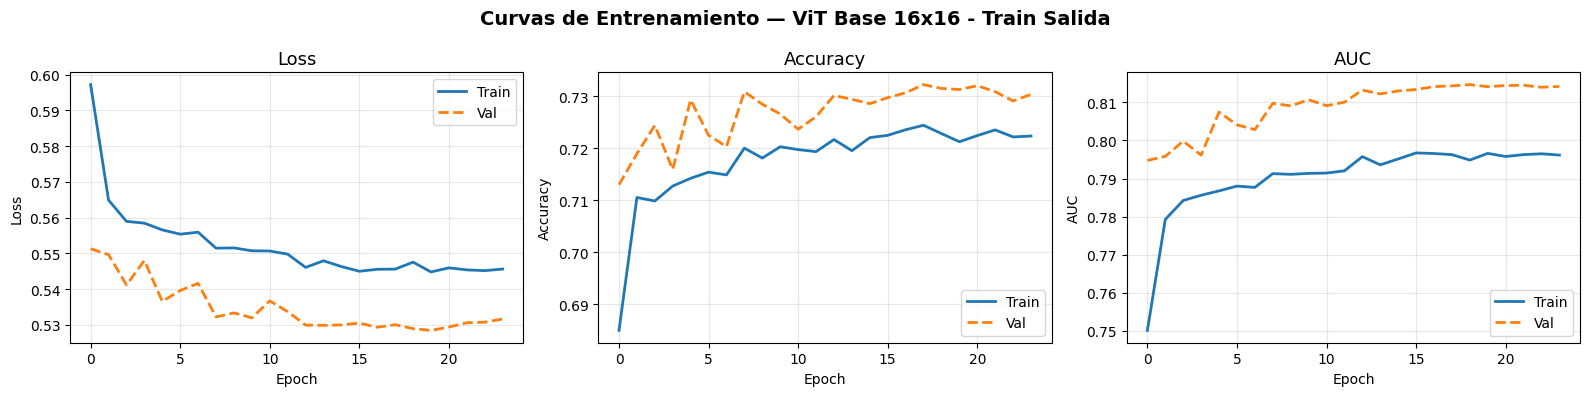

In [7]:
def plot_history(hist):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [
        ('loss',     'Loss',     'Loss'),
        ('accuracy', 'Accuracy', 'Accuracy'),
        ('auc',      'AUC',      'AUC'),
    ]
    for ax, (key, title, ylabel) in zip(axes, metrics):
        ax.plot(hist.history[key],     label='Train', linewidth=2)
        ax.plot(hist.history[f'val_{key}'], label='Val', linewidth=2, linestyle='--')
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle('Curvas de Entrenamiento — ViT Base 16x16 - Train Salida', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves_vit_salida.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(hist)

In [8]:
print("=" * 45)
print("EVALUACIÓN FINAL SOBRE TEST SET")
print("=" * 45)
test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=1)
print(f"\nLoss:     {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"AUC:      {test_auc:.4f}")

EVALUACIÓN FINAL SOBRE TEST SET
 16/374 ━━━━━━━━━━━━━━━━━━━━ 1:06 185ms/step - accuracy: 0.7352 - auc: 0.8177 - loss: 0.5260

2026-06-04 10:06:59.526833: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


140/374 ━━━━━━━━━━━━━━━━━━━━ 40s 172ms/step - accuracy: 0.7276 - auc: 0.8157 - loss: 0.5254

Corrupt JPEG data: premature end of data segment


337/374 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - accuracy: 0.7293 - auc: 0.8140 - loss: 0.5283

2026-06-04 10:07:54.325453: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


372/374 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7298 - auc: 0.8140 - loss: 0.5283

2026-06-04 10:08:00.486665: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 4 bytes spill stores, 4 bytes spill loads

2026-06-04 10:08:00.872688: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 132 bytes spill stores, 132 bytes spill loads

2026-06-04 10:08:00.921830: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 736 bytes spill stores, 736 bytes spill loads

2026-06-04 10:08:00.922251: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 4 bytes spill stores, 4 bytes spill loads

2026-06-04 10:08:01.161716: I external/local_xla/xla/stream_executor

374/374 ━━━━━━━━━━━━━━━━━━━━ 66s 176ms/step - accuracy: 0.7347 - auc: 0.8159 - loss: 0.5269

Loss:     0.5269
Accuracy: 0.7347  (73.47%)
AUC:      0.8159


In [ ]:
y_true_list = []
y_pred_list = []
y_prob_list = []

for x_batch, y_batch in test_ds:
    y_true_list.extend(y_batch.numpy())

    probs = model.predict_on_batch(x_batch)
    y_prob_list.extend(probs.flatten())
    y_pred_list.extend((probs > 0.5).astype(int).flatten())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_prob = np.array(y_prob_list)

print("Distribución y_true:", np.bincount(y_true))
print("Distribución y_pred:", np.bincount(y_pred))

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: images
Received: inputs=['Tensor(shape=(32, 224, 224, 3))']
  warnings.warn(msg)


Distribución y_true: [5970 5995]
Distribución y_pred: [5588 6377]


2026-06-04 10:08:44.902598: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


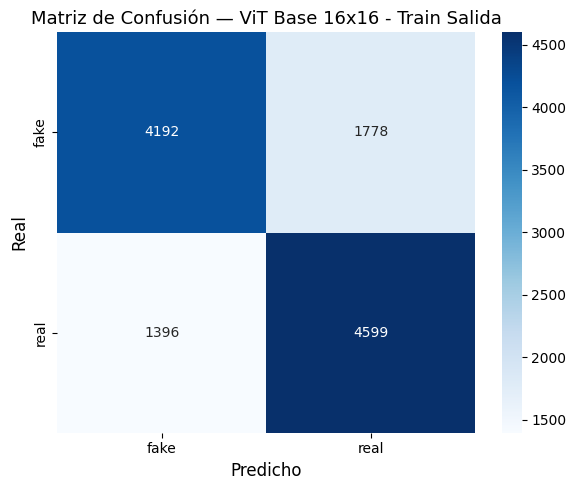


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fake       0.75      0.70      0.73      5970
        real       0.72      0.77      0.74      5995

    accuracy                           0.73     11965
   macro avg       0.74      0.73      0.73     11965
weighted avg       0.74      0.73      0.73     11965



In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión — ViT Base 16x16 - Train Salida', fontsize=13)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/confusion_matrix_vit_salida_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=class_names))

Imagen guardada como classification_report.png


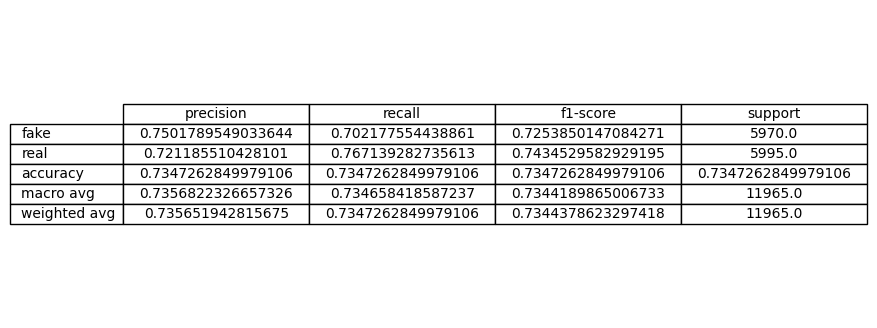

In [ ]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=df_report.values, 
                 colLabels=df_report.columns, 
                 rowLabels=df_report.index, 
                 cellLoc='center', 
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.savefig('/workspace/imagenes_metricas_full_dataset/classification_report_vit_salida_final.png', bbox_inches='tight', dpi=300)
print("Imagen guardada como classification_report.png")

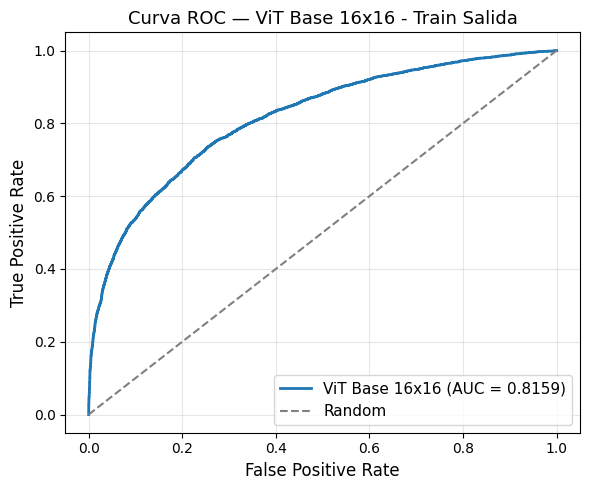

AUC final (test completo): 0.8159


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_score   = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'ViT Base 16x16 (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC — ViT Base 16x16 - Train Salida', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_full_dataset/roc_curve_vit_salida_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC final (test completo): {auc_score:.4f}")